In [327]:
import os
#import deeptile
import matplotlib.pyplot as plt
import numpy as np
# from deeptile.extensions import stitch
import tifffile
import dask.array as da
import utils
import skimage as ski
from find_neighbors import objects_bounds
# import extract_features
import pandas as pd
#from collections import defaultdict
#from extract_features import features_basic, foci_features, feature_table, neighbor_measurements
#from scipy import ndimage as ndi
import time
import extract_features
import ast
from brieflow_segment_utils import image_log_scale
from scipy import ndimage as ndi

In [ ]:
ski.feature.peak_local_max()

In [375]:
import importlib
importlib.reload(utils)

<module 'utils' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/current/utils.py'>

In [187]:
nuclei_mask_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered_nuclei.tif"
foci_mask_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered_foci.tif"
cy5_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12_cy5.ome.tif"
gfp_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12_gfp.ome.tif"
coverslip_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_coverslip.tif"

#masks = da.stack((da.from_zarr(tifffile.imread(nuclei_mask_path, aszarr=True)),da.from_zarr(tifffile.imread(foci_mask_path, aszarr=True))), axis=0)
img = tifffile.memmap(cy5_path)
gfp = tifffile.memmap(gfp_path)
nuclei = tifffile.memmap(nuclei_mask_path)
# results_fullslide = pd.read_csv(results_path,dtype={"nucleus_bounds":"object"}).set_index("label", drop=True)
# results_fullslide["nucleus_bounds"] = results_fullslide["nucleus_bounds"].apply(ast.literal_eval)

In [292]:
minimums_i, maximums_i, minimums_j, maximums_j = objects_bounds(nuclei, 400)

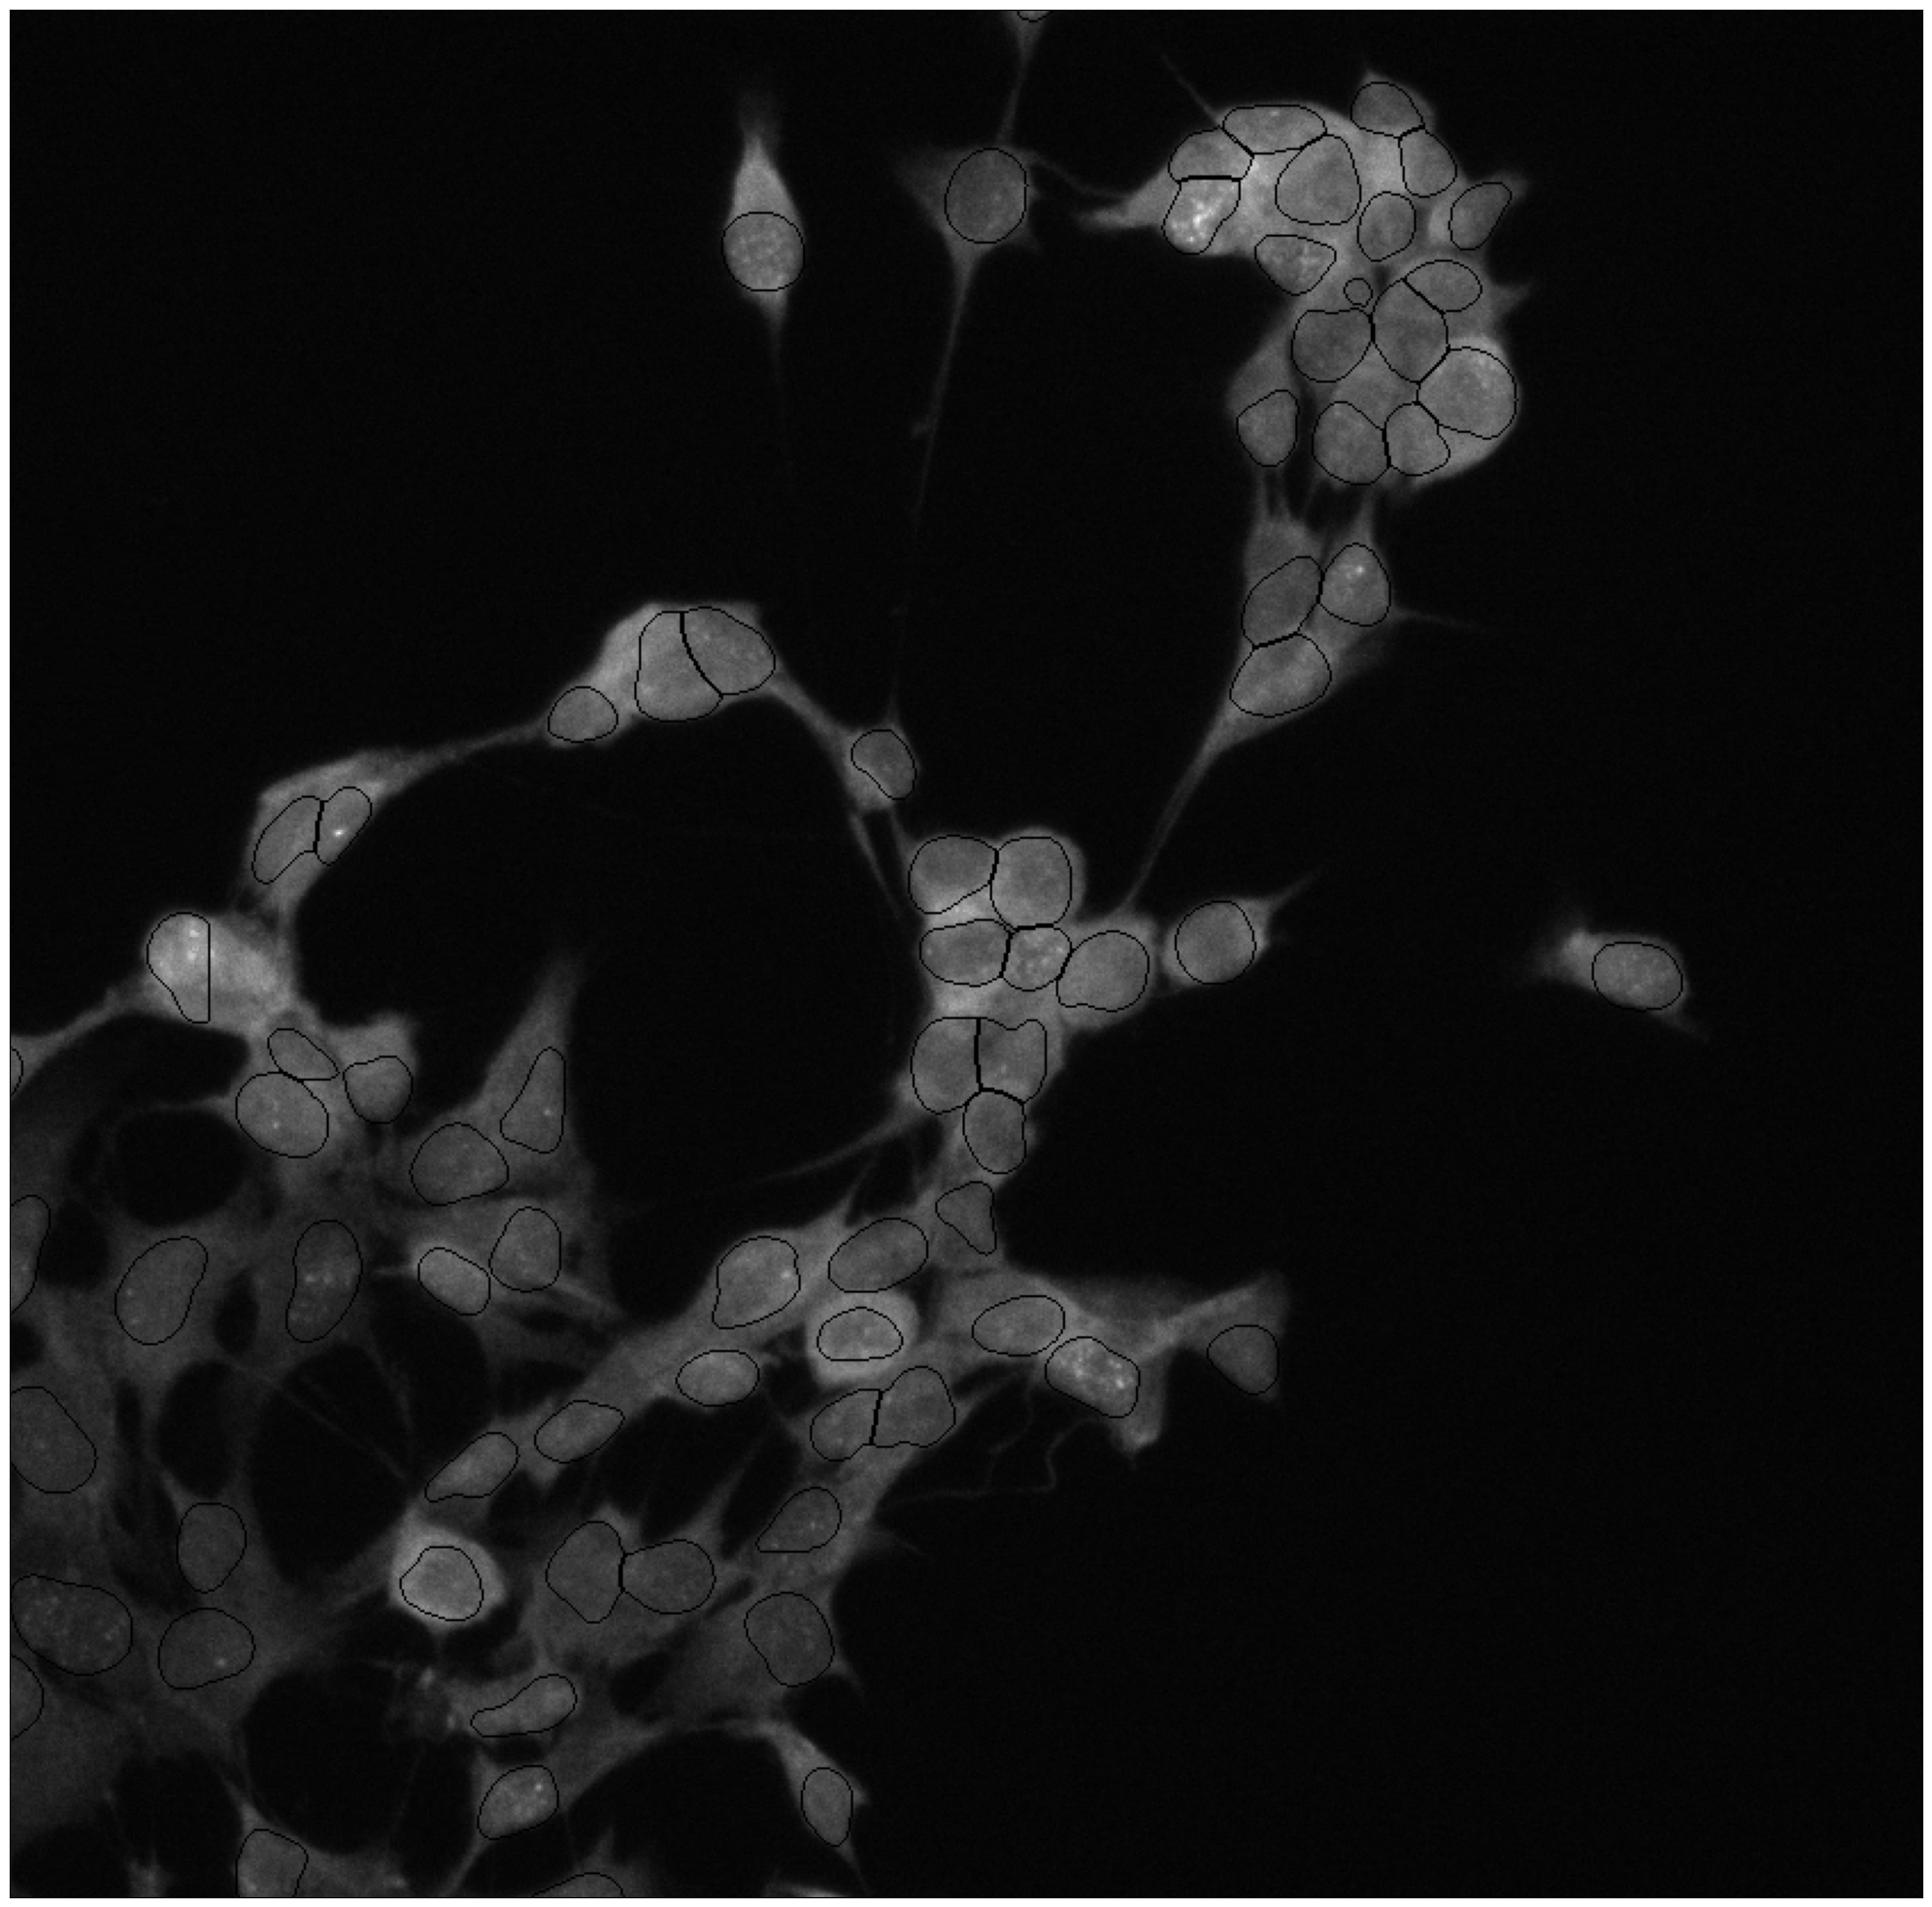

In [381]:
k = 777
patch_img = img[
    minimums_i[k] : maximums_i[k],
    minimums_j[k] : maximums_j[k],
]

patch_gfp = gfp[
    minimums_i[k] : maximums_i[k],
    minimums_j[k] : maximums_j[k],
]

patch_nuclei = nuclei[
    minimums_i[k] : maximums_i[k],
    minimums_j[k] : maximums_j[k],
]

patch_mask = patch_nuclei == k+1
# patch_img_masked = np.where(patch_mask, patch_img, 0)
patch_img_masked = patch_img*(patch_nuclei>0)

nuc_outline = ski.segmentation.find_boundaries(patch_nuclei,mode="outer")
nuc_outline = np.ma.masked_where(nuc_outline==False,nuc_outline)

fig,ax = plt.subplots(figsize=(20,20))
ax.imshow((patch_img),cmap="gray")
ax.imshow(nuc_outline, cmap="Grays_r")
ax.set_yticks([])
ax.set_xticks([])
plt.tight_layout()

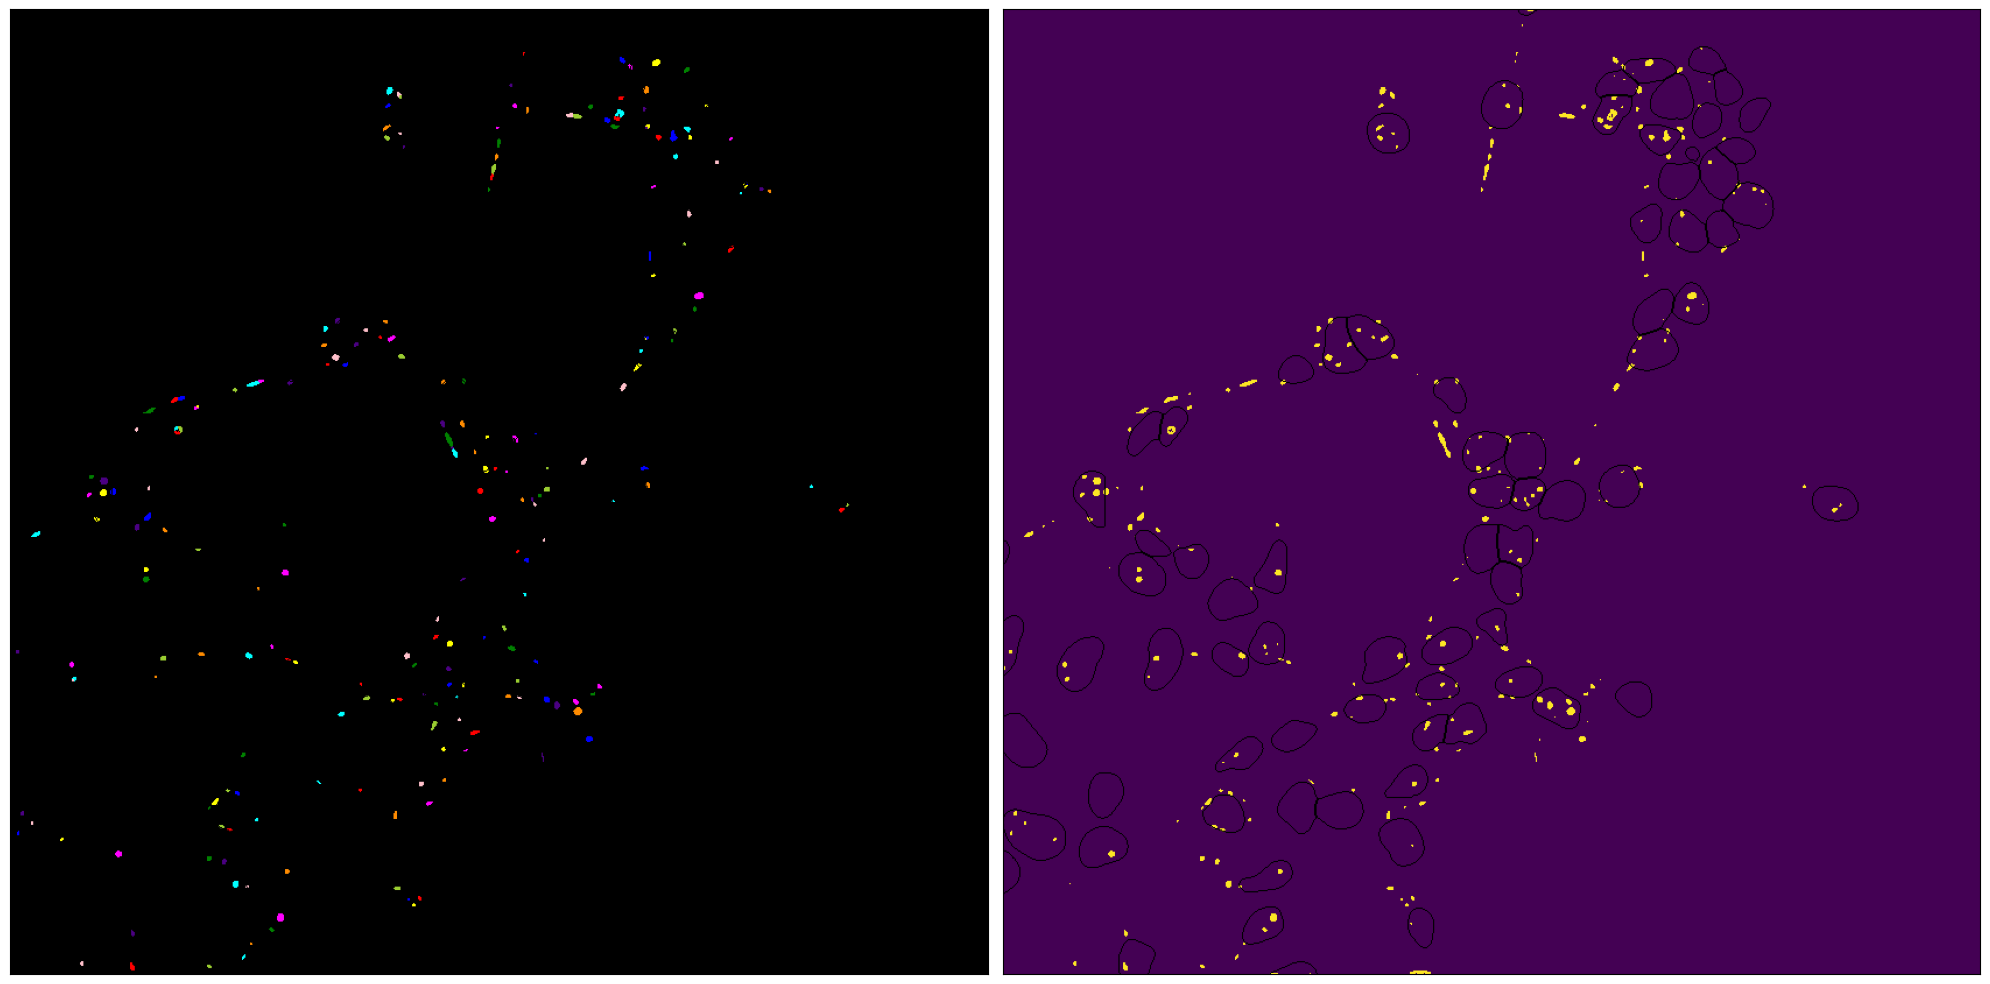

In [373]:
tophat = ski.morphology.white_tophat(
        patch_img, footprint=ski.morphology.disk(2))
tophat_log = utils.log_ndi(tophat, sigma=3)

tophat_log=ski.morphology.remove_small_objects(tophat_log, min_size=(2**2))
tophat_log = tophat_log>5
labeled = ski.measure.label(tophat_log)
water = utils.apply_watershed(labeled, smooth=1, min_distance=1)
water = ski.morphology.remove_small_objects(water, min_size=(2**2))
fig,ax=plt.subplots(ncols=2,figsize=(20,10))
ax[0].imshow(ski.color.label2rgb(water))
ax[0].imshow(nuc_outline, cmap="Grays_r")
ax[1].imshow(tophat_log)
ax[1].imshow(nuc_outline, cmap="Grays_r")
for a in ax:
    a.set_yticks([])
    a.set_xticks([])
plt.tight_layout()

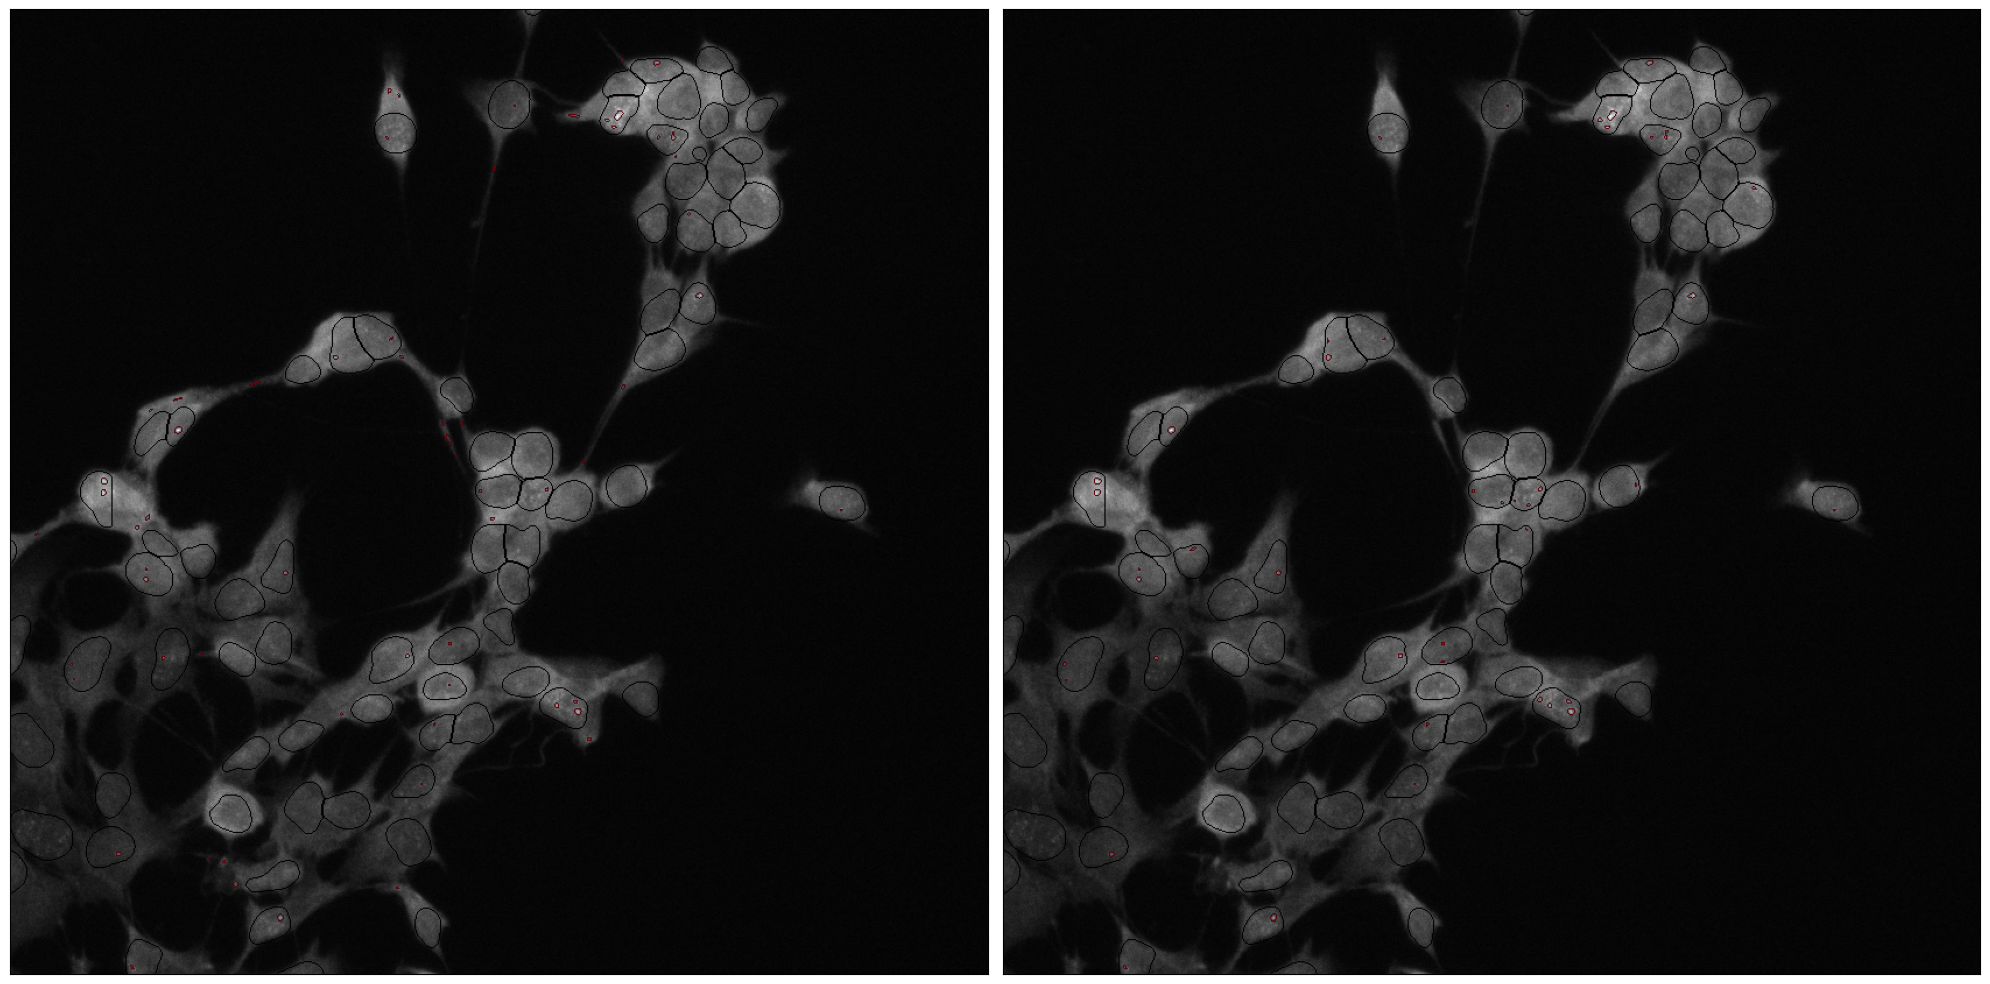

In [382]:
kwargs_noregions = {"radius":2, "sigma":3,"threshold":7, "min_distance":1, "remove_border_foci":True, "border_mask":patch_nuclei}
foci_masked = utils.find_foci(patch_img_masked, **kwargs_noregions)
foci = utils.find_foci(patch_img, **kwargs_noregions)

foci_outline = ski.segmentation.find_boundaries(foci,mode="inner")
foci_outline = np.ma.masked_where(foci_outline==False,foci_outline)

foci_outline_masked = ski.segmentation.find_boundaries(foci_masked,mode="inner")
foci_outline_masked = np.ma.masked_where(foci_outline_masked==False,foci_outline_masked)

fig,ax=plt.subplots(ncols=2,figsize=(20,20))
ax[0].imshow(patch_img, cmap="gray")
ax[0].imshow(foci_outline,cmap="Reds_r")
ax[0].imshow(nuc_outline, cmap="Grays_r")
ax[0].set_yticks([])
ax[0].set_xticks([])

ax[1].imshow(patch_img, cmap="gray")
ax[1].imshow(foci_outline_masked,cmap="Reds_r")
ax[1].imshow(nuc_outline, cmap="Grays_r")
ax[1].set_yticks([])
ax[1].set_xticks([])
plt.tight_layout()

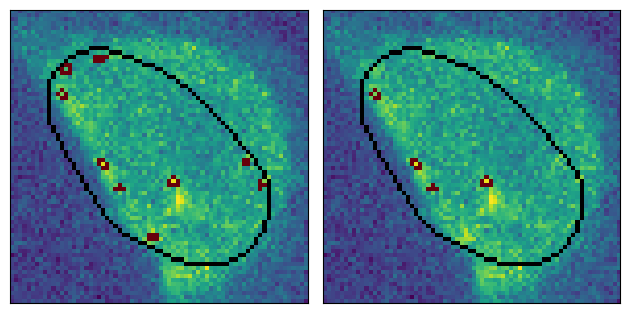

In [291]:
kwargs_regions = {"radius":2, "threshold":10, "min_distance":2, "regions":patch_nuclei, "remove_border_foci":False}
kwargs_noregions = {"radius":2, "threshold":10, "min_distance":2, "remove_border_foci":True, "border_mask":patch_nuclei}


yesregions = utils.find_foci(patch_img_masked, **kwargs_regions)
noregions = utils.find_foci(patch_img_masked, **kwargs_noregions)

foci_outline = ski.segmentation.find_boundaries(noregions,mode="inner")
foci_outline = np.ma.masked_where(foci_outline==False,foci_outline)

foci_outline_regions = ski.segmentation.find_boundaries(yesregions,mode="inner")
foci_outline_regions = np.ma.masked_where(foci_outline_regions==False,foci_outline_regions)


fig,ax=plt.subplots(ncols=2)
ax[0].imshow(patch_img)
ax[0].imshow(foci_outline_regions,cmap="Reds_r")
ax[0].imshow(nuc_outline, cmap="Grays_r")

ax[1].imshow(patch_img)
ax[1].imshow(foci_outline,cmap="Reds_r")
ax[1].imshow(nuc_outline, cmap="Grays_r")

for a in ax:
    a.set_yticks([])
    a.set_xticks([])
plt.tight_layout()

In [ ]:
start_seg_foci = time.time()

#import_masks_nuclei = tiles_foci.import_data(mask_nuclei, "image").unpad().pad() # need to unpad, pad bc bug in package code
# segment foci and stitch
kwargs = {"radius":2, "threshold":25, "min_distance":1, "regions":import_masks_nuclei, "remove_border_foci":True}
masks_foci = utils.segment_foci_tiled(tiles_foci, **kwargs)
mask_foci = stitch.stitch_masks(masks_foci)

finish_seg_foci = time.time()

# save mask
foci_mask_file = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered_foci.tif"
tifffile.imwrite(foci_mask_file, mask_foci.astype(dt_foci.image.dtype))

print(finish_seg_foci-start_seg_foci)

In [ ]:
fig, ax = plt.subplots(figsize=(20,20))
ax.imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img_foci[16826:16826+6144,16826:16826+6144], in_range=(0,3000)), mask_foci[16826:16826+6144,16826:16826+6144].compute()), mask_nuclei[16826:16826+6144,16826:16826+6144].compute(), color=(1,0,1)), cmap='gray')

In [ ]:
from extract_features import feature_table
add_props = {"label": lambda r: r.label,
            "intensity_min": lambda r: r.intensity_min,
             "intensity_std": lambda r: r.intensity_std,
             "eccentricity": lambda r: r.eccentricity
}
start_feature_extract = time.time()

dfs = []
dfs.append(
    feature_table(masks[0], add_props, img[0])
    .set_index("label")
    .add_prefix("nucleus_")
)

dfs.append(
    results_fullslide
)

finish_feature_extract = time.time()

results_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered2.csv"

results_fullslide = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label", drop=True)
results_fullslide.to_csv(results_path)
print(finish_feature_extract-start_feature_extract)


In [ ]:
samp = results_fullslide.sort_values(by="nucleus_eccentricity", ascending=False).head(n=10)
inspect = samp.index
sub = [
    extract_features.subimage(img, results_fullslide.at[i,"nucleus_bounds"], pad=50)
    for i in inspect
]
sub_mask = [
    extract_features.subimage(masks, results_fullslide.at[i,"nucleus_bounds"], pad=50)
    for i in inspect
]

In [ ]:
samp

In [ ]:
fig, ax = plt.subplots(2,5, figsize=(20,10))
for i, (base, line) in enumerate(zip(sub, sub_mask)):
    #ax[i//5,i%5].imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(base[1], in_range=(0,4000)),line[1]), line[0], color=(1,0,1)), cmap='gray')
    ax[i//5,i%5].imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(base[0], in_range=(0,4000)), line[0], color=(1,0,1)), cmap='gray')
    ax[i//5,i%5].set_yticks([])
    ax[i//5,i%5].set_xticks([])
plt.tight_layout()
#ax[1].imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(sub[1], in_range=(0,12000)), sub_mask[1]), sub_mask[0], color=(1,0,1)), cmap='gray')
# for a in ax:
#     a.set_yticks([])
#     a.set_xticks([])

In [ ]:
results_fullslide[results_fullslide["nucleus_intensity_mean"]<1000].sort_values(by="nucleus_intensity_max",ascending=False).head(n=10).index

In [ ]:
# fig, ax = plt.subplots(2, 2, figsize=(20, 20))
# ds = 5

# ax[0,0].imshow(ski.exposure.rescale_intensity(img_nuclei[::ds,::ds].compute(), in_range=(0,6000)), cmap="gray")
# ax[0,0].contour(coverslip_mask[::ds,::ds], colors="red", linewidths=0.7)
# ax[0,0].set_title("full image")
# ax[0,0].set_yticks([])
# ax[0,0].set_xticks([]) 

# ax[0,1].imshow(ski.exposure.rescale_intensity(img_nuclei[::ds,::ds].compute(), in_range=(0,6000))*coverslip_mask[::ds,::ds], cmap="gray")
# ax[0,1].contour(coverslip_mask[::ds,::ds], colors="red", linewidths=0.7)
# ax[0,1].set_title("coverslip filter")
# ax[0,1].set_yticks([])
# ax[0,1].set_xticks([]) 

# ax[1,0].imshow(ski.color.label2rgb(nuclei_mask[::ds,::ds].compute()))
# ax[1,0].contour(coverslip_mask[::ds,::ds], colors="red", linewidths=0.7)
# ax[1,0].set_title("labeled")
# ax[1,0].set_yticks([])
# ax[1,0].set_xticks([]) 

# ax[1,1].imshow(ski.color.label2rgb(nuclei_mask[::ds,::ds].compute()*coverslip_mask[::ds,::ds]))
# ax[1,1].contour(coverslip_mask[::ds,::ds], colors="red", linewidths=0.7)
# ax[1,1].set_title("filtered")
# ax[1,1].set_yticks([])
# ax[1,1].set_xticks([]) 

# plt.tight_layout()
# plt.show()